<a href="https://colab.research.google.com/github/brandim04/AnaliseDeDados/blob/main/Simula%C3%A7%C3%A3o_de_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

**2. Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. Desafio

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.Dicas:Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

In [3]:
def simular_lucro(vendas_media, vendas_desvio, custo_min, custo_max, preco_venda, investimento_fixo, n_simulacoes=10000):
    vendas = np.random.normal(vendas_media, vendas_desvio, n_simulacoes)
    custo_unitario = np.random.uniform(custo_min, custo_max, n_simulacoes)
    lucro = (vendas * preco_venda) - (vendas * custo_unitario) - investimento_fixo
    return lucro

lucro_a = simular_lucro(vendas_media_a, vendas_desvio_a, custo_min_a, custo_max_a, preco_venda_a, investimento_fixo_a)
lucro_b = simular_lucro(vendas_media_b, vendas_desvio_b, custo_min_b, custo_max_b, preco_venda_b, investimento_fixo_b)

print("Estrategia A")
print(f"Lucro Médio:    R$ {lucro_a.mean():,.2f}")
print(f"Desvio Padrão:  R$ {lucro_a.std():,.2f}")
print(f"Lucro Mínimo:   R$ {lucro_a.min():,.2f}")
print(f"Lucro Máximo:   R$ {lucro_a.max():,.2f}")

print("\nEstratgia B")
print(f"Lucro Médio:    R$ {lucro_b.mean():,.2f}")
print(f"Desvio Padrão:  R$ {lucro_b.std():,.2f}")
print(f"Lucro Mínimo:   R$ {lucro_b.min():,.2f}")
print(f"Lucro Máximo:   R$ {lucro_b.max():,.2f}")

Estrategia A
Lucro Médio:    R$ 225,076.84
Desvio Padrão:  R$ 31,078.89
Lucro Mínimo:   R$ 113,319.86
Lucro Máximo:   R$ 340,088.45

Estratgia B
Lucro Médio:    R$ 169,473.80
Desvio Padrão:  R$ 138,207.85
Lucro Mínimo:   R$ -220,112.71
Lucro Máximo:   R$ 787,943.17


**2: Visualização dos Resultados**

Gere um histograma comparando as duas estratégias. O gráfico deve ajudar a diretoria a visualizar onde o lucro se concentra e onde estão os riscos de perda (valores abaixo de zero).

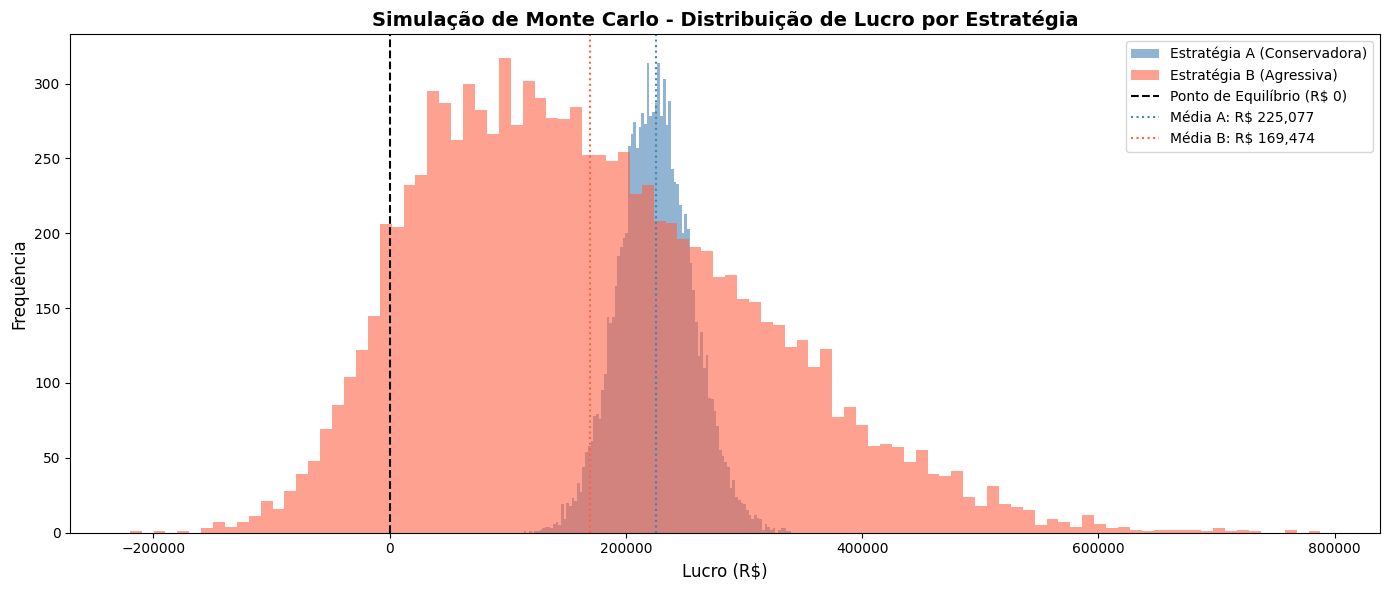

In [4]:
plt.figure(figsize=(14, 6))

plt.hist(lucro_a, bins=100, alpha=0.6, color='steelblue', label='Estratégia A (Conservadora)')
plt.hist(lucro_b, bins=100, alpha=0.6, color='tomato', label='Estratégia B (Agressiva)')

plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Ponto de Equilíbrio (R$ 0)')
plt.axvline(x=lucro_a.mean(), color='steelblue', linestyle=':', linewidth=1.5, label=f'Média A: R$ {lucro_a.mean():,.0f}')
plt.axvline(x=lucro_b.mean(), color='tomato', linestyle=':', linewidth=1.5, label=f'Média B: R$ {lucro_b.mean():,.0f}')

plt.title('Simulação de Monte Carlo - Distribuição de Lucro por Estratégia', fontsize=14, fontweight='bold')
plt.xlabel('Lucro (R$)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

**3: Cálculo de Probabilidades**
Calcule e exiba as seguintes métricas para cada estratégia:

Média de Lucro.

Probabilidade de Prejuízo (porcentagem de simulações onde o lucro foi < 0).

In [7]:
p_prejuizo_a = (lucro_a < 0).mean() * 100
p_prejuizo_b = (lucro_b < 0).mean() * 100

print("Estategia A")
print(f"Média de Lucro:R$ {lucro_a.mean():,.2f}")
print(f"Probabilidade de Prejuízo: {p_prejuizo_a:.2f}%")

print("\nEstrategia B")
print(f"Média de Lucro: R$ {lucro_b.mean():,.2f}")
print(f"Probabilidade de Prejuízo: {p_prejuizo_b:.2f}%")

Estategia A
Média de Lucro:R$ 225,076.84
Probabilidade de Prejuízo: 0.00%

Estrategia B
Média de Lucro: R$ 169,473.80
Probabilidade de Prejuízo: 8.88%
